<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/Ponencia_Parte_3_Regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión


In [4]:
import pandas as pd
# Vamos a trabajar con un dataset de regresión (diabetes)
from sklearn.datasets import load_diabetes
# Este dataset contiene información médica de 442 pacientes.
# Hay 10 variables numéricas por paciente, como edad, índice de masa corporal,
# presión sanguínea y otros indicadores relacionados con la diabetes.
# El objetivo es una medida continua de progresión de la enfermedad después de un año.
data = load_diabetes()
X = data.data
y = data.target
# Mostrar las primeras filas del dataset como tabla
# Convertimos los datos a un DataFrame para verlo mejor
X_df = pd.DataFrame(data.data, columns=data.feature_names)
X_df['target'] = data.target
print(X_df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


##SGD

     eta0           MSE           MAE          RMSE            R2
1  0.0010  3.156820e+03  4.550000e+01  5.619000e+01  4.963000e-01
0  0.0001  3.178080e+03  4.581000e+01  5.637000e+01  4.929000e-01
2  0.0100  3.324500e+03  4.689000e+01  5.766000e+01  4.695000e-01
3  0.1000  5.009190e+03  5.481000e+01  7.078000e+01  2.007000e-01
4  1.0000  5.522319e+25  6.098741e+12  7.431231e+12 -8.811745e+21


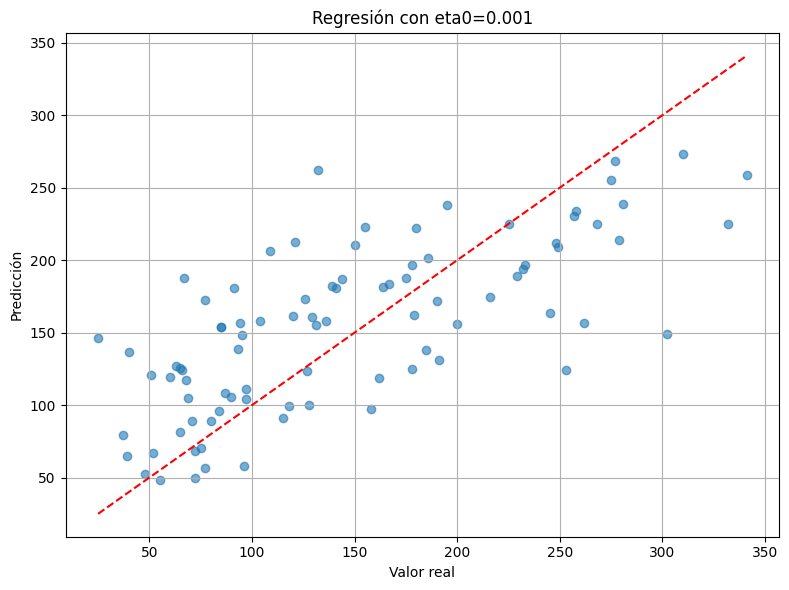

In [5]:
# Regresión para minimizar el error

from sklearn.datasets import load_diabetes
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Cargar un dataset de regresión (diabetes)
data = load_diabetes()
X = data.data
y = data.target

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2025)

# Lista de tasas de aprendizaje
etas = [0.0001, 0.001, 0.01, 0.1, 1.0]

resultados = []

for eta in etas:
    model = SGDRegressor(learning_rate='constant', eta0=eta, max_iter=1000, random_state=2025)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'eta0': eta,
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

# Mostrar resultados ordenados por MSE
df_resultados = pd.DataFrame(resultados)
print(df_resultados.sort_values(by='MSE'))

# Visualizar las predicciones del mejor modelo
mejor_eta = df_resultados.sort_values(by='MSE').iloc[0]['eta0']
mejor_modelo = SGDRegressor(learning_rate='constant', eta0=mejor_eta, max_iter=1000, random_state=2025)
mejor_modelo.fit(X_train, y_train)
y_pred_mejor = mejor_modelo.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_mejor, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Regresión con eta0={mejor_eta}")
plt.grid(True)
plt.tight_layout()
plt.show()

# Explicación:
# - El objetivo es minimizar el error (MSE)
# - Probamos diferentes tasas de aprendizaje (eta0)
# - Seleccionamos la que da menor MSE en el conjunto de prueba
# - Visualizamos las predicciones frente a los valores reales

#¿MSE?
# MSE = Mean Squared Error (Error cuadrático medio)
# Calcula el promedio de los errores al cuadrado entre la predicción y el valor real.
# Penaliza más los errores grandes.
# Cuanto más bajo, mejor. Su unidad es la del target al cuadrado.

# ¿Y MAE?
# MAE mide el error promedio absoluto entre la predicción y el valor real.
# No penaliza tanto los errores grandes como el MSE.
# Es más interpretable porque está en la misma unidad que la salida (target).

# ¿Y RMSE?
# RMSE es la raíz cuadrada del MSE.
# Tiene la ventaja de estar en la misma escala que el target.
# Penaliza más los errores grandes, pero es más interpretable que el MSE.

# ¿Y R2?
# R2 indica qué proporción de la variabilidad del target explica el modelo.
# Va de -∞ a 1 (ideal = 1).
# Un R2 cercano a 0 significa que el modelo no explica mejor que adivinar la media.

# ¿Cuál usar?
# MSE	Comparar sensibilidad a errores grandes
# MAE	Interpretación simple y robusta
# RMSE	MSE ajustado a la escala real del target
# R2	Entender el poder explicativo del modelo

In [6]:
"""
eta0         MSE           MAE          RMSE            R²
0.0010  3.156820e+03  4.550000e+01  5.619000e+01  4.963000e-01
0.0001  3.178080e+03  4.581000e+01  5.637000e+01  4.929000e-01
0.0100  3.324500e+03  4.689000e+01  5.766000e+01  4.695000e-01
0.1000  5.009190e+03  5.481000e+01  7.078000e+01  2.007000e-01
1.0000  5.522319e+25  6.098741e+12  7.431231e+12 -8.811745e+21

eta0 entre 0.001 y 0.001:
MSE y RMSE bajos, MAEs cercanos y un R² aprox a 0.5.
Estos valores indican que el modelo aprende progresivamente y no se desestabiliza.
R² en torno a 0.50 significa que el modelo explica aproximadamente el 50% de la variabilidad.

eta0 entre 0.01 y 0.1:
¿Qué courre a MSE? ¿Y a R²? Empiezan a aumentar el MSE y bajar el R².
Esto indica que el modelo ya está dando pasos demasiado grandes, no ajusta bien los pesos y pierde precisión.

eta0 = 1.0
Locurón total.
"""

'\neta0         MSE           MAE          RMSE            R²\n0.0010  3.156820e+03  4.550000e+01  5.619000e+01  4.963000e-01\n0.0001  3.178080e+03  4.581000e+01  5.637000e+01  4.929000e-01\n0.0100  3.324500e+03  4.689000e+01  5.766000e+01  4.695000e-01\n0.1000  5.009190e+03  5.481000e+01  7.078000e+01  2.007000e-01\n1.0000  5.522319e+25  6.098741e+12  7.431231e+12 -8.811745e+21\n\neta0 entre 0.001 y 0.001:\nMSE y RMSE bajos, MAEs cercanos y un R² aprox a 0.5.\nEstos valores indican que el modelo aprende progresivamente y no se desestabiliza.\nR² en torno a 0.50 significa que el modelo explica aproximadamente el 50% de la variabilidad.\n\neta0 entre 0.01 y 0.1:\n¿Qué courre a MSE? ¿Y a R²? Empiezan a aumentar el MSE y bajar el R².\nEsto indica que el modelo ya está dando pasos demasiado grandes, no ajusta bien los pesos y pierde precisión.\n\neta0 = 1.0\nLocurón total.\n'

In [7]:
# ¿Podemos seguir afinando?
# Podemos definir diferentes maneras de aprender (learning_rate)

# Estrategia para mantener el learning_rate constante:
# Estrategia 'constant': eta0 se mantiene igual durante todo el entrenamiento

resultados_constant = []
for eta in etas:
    model = SGDRegressor(learning_rate='constant', eta0=eta, max_iter=1000, random_state=2025)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_constant.append({
        'strategy': 'constant',
        'eta0': eta,
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

# Resultados
print("Resultados con learning_rate='constant'")
df_constant = pd.DataFrame(resultados_constant)
print(df_constant.sort_values(by='MSE'))

Resultados con learning_rate='constant'
   strategy    eta0           MSE           MAE          RMSE            R2
1  constant  0.0010  3.156820e+03  4.550000e+01  5.619000e+01  4.963000e-01
0  constant  0.0001  3.178080e+03  4.581000e+01  5.637000e+01  4.929000e-01
2  constant  0.0100  3.324500e+03  4.689000e+01  5.766000e+01  4.695000e-01
3  constant  0.1000  5.009190e+03  5.481000e+01  7.078000e+01  2.007000e-01
4  constant  1.0000  5.522319e+25  6.098741e+12  7.431231e+12 -8.811745e+21


In [8]:
# Estrategia 'adaptive'
# En 'adaptive', eta0 baja automáticamente solo si el modelo deja de mejorar
resultados_adaptive = []
for eta in etas:
    model = SGDRegressor(learning_rate='adaptive', eta0=eta, max_iter=1000, random_state=2025)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_adaptive.append({
        'strategy': 'adaptive',
        'eta0': eta,
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

print("\nResultados con learning_rate='adaptive'")
df_adaptive = pd.DataFrame(resultados_adaptive)
print(df_adaptive.sort_values(by='MSE'))


Resultados con learning_rate='adaptive'
   strategy    eta0      MSE    MAE   RMSE      R2
2  adaptive  0.0100  3175.95  45.82  56.36  0.4932
3  adaptive  0.1000  3177.20  45.92  56.37  0.4930
0  adaptive  0.0001  3177.78  45.81  56.37  0.4929
1  adaptive  0.0010  3177.83  45.81  56.37  0.4929
4  adaptive  1.0000  3179.00  45.81  56.38  0.4927


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [9]:
# Estrategia 'invscaling'
# En 'invscaling', eta0 baja suavemente con cada iteración

resultados_invscaling = []
for eta in etas:
    model = SGDRegressor(learning_rate='invscaling', eta0=eta, max_iter=1000, random_state=2025)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_invscaling.append({
        'strategy': 'invscaling',
        'eta0': eta,
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

print("\nResultados con learning_rate='invscaling'")
df_invscaling = pd.DataFrame(resultados_invscaling)
print(df_invscaling.sort_values(by='MSE'))


Resultados con learning_rate='invscaling'
     strategy    eta0      MSE    MAE   RMSE      R2
3  invscaling  0.1000  3107.19  45.04  55.74  0.5042
2  invscaling  0.0100  3166.61  45.67  56.27  0.4947
1  invscaling  0.0010  3177.41  45.80  56.37  0.4930
0  invscaling  0.0001  3335.08  45.71  57.75  0.4678
4  invscaling  1.0000  5687.09  61.38  75.41  0.0925


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## Random Forest Regessor

In [10]:
# No necesita escalado:

from sklearn.ensemble import RandomForestRegressor

# Cargar el dataset de nuevo sin escalar (puede funcionar mejor en árboles)
data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Entrenar un modelo de Random Forest con 100 árboles
rf = RandomForestRegressor(n_estimators=100, random_state=2025)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nEvaluación del modelo Random Forest:")
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

# ¿Podemos mejorarlo? Hay parámetros que editar:
# n_estimators: número de árboles del bosque
#    Más árboles pueden mejorar el rendimiento, pero hacen el modelo más lento.

# max_depth: profundidad máxima de cada árbol
#    Controla cuánto puede crecer cada árbol (evita sobreajuste si se limita bien).

# min_samples_split: número mínimo de muestras para dividir un nodo
#    Aumentarlo fuerza a los árboles a ser más generales.

# min_samples_leaf: número mínimo de muestras en una hoja
#    Evita hojas muy pequeñas (mejor generalización).

# max_features: número de características a usar en cada división
#    'auto', 'sqrt', 'log2' o un número. Menos características = más diversidad entre árboles.



Evaluación del modelo Random Forest:
MSE: 3583.08
MAE: 50.22
RMSE: 59.86
R2: 0.4283


In [11]:
from sklearn.ensemble import RandomForestRegressor

# Cargar el dataset de nuevo sin escalar (puede funcionar mejor en árboles)
data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Optimización de hiperparámetros con GridSearchCV
from sklearn.model_selection import GridSearchCV

# Definimos una rejilla con múltiples valores para probar
param_grid = {
    'n_estimators': [50, 100, 200, 300],              # número de árboles
    'max_depth': [None, 5, 10, 20, 30],               # profundidad máxima
    'min_samples_split': [2, 5, 10],                  # mínimo de muestras para dividir
    'min_samples_leaf': [1, 2, 4],                    # mínimo de muestras en una hoja
    'max_features': ['auto', 'sqrt', 'log2']          # número de variables por división
}

# Creamos el modelo base
rf_base = RandomForestRegressor(random_state=2025)

# Buscamos la mejor combinación de hiperparámetros
grid_search = GridSearchCV(estimator=rf_base,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=2,
                           n_jobs=-1,
                           verbose=1)

# Valores para el SCORING:
#'neg_mean_squared_error'	Error cuadrático medio (MSE, más penalización a errores grandes)
#'neg_root_mean_squared_error'	Raíz del MSE (RMSE, misma unidad que el target)
#'neg_mean_absolute_error'	Error absoluto medio (MAE, más interpretable)
# 'r2'	Coeficiente de determinación (0 a 1, mejor es más cercano a 1)

# Paralelización en el número de jobs
# n_jobs=1	Solo usa un núcleo (ejecución secuencial)
# n_jobs=2	Usa 2 núcleos (paralelismo limitado)
# n_jobs=-1	Usa todos los núcleos disponibles

grid_search.fit(X_train, y_train)

# Obtenemos el mejor modelo y lo evaluamos
y_pred = grid_search.best_estimator_.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Evaluación del mejor modelo Random Forest tras GridSearch:")
print("Mejores hiperparámetros:", grid_search.best_params_)
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))
rf = RandomForestRegressor(n_estimators=100, random_state=2025)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nEvaluación del modelo Random Forest:")
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

Fitting 2 folds for each of 540 candidates, totalling 1080 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
360 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

Evaluación del mejor modelo Random Forest tras GridSearch:
Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
MSE: 3480.27
MAE: 49.97
RMSE: 58.99
R2: 0.4447

Evaluación del modelo Random Forest:
MSE: 3583.08
MAE: 50.22
RMSE: 59.86
R2: 0.4283


## L2 y L2 (Ridge y Lasso)

In [12]:
# Regresión con Ridge y Lasso

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos y escalar
data = load_diabetes()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2025)

# Definimos valores de alpha (tasa de regularización)
# Alpha controla cuánto penalizamos los coeficientes grandes.
# Valores pequeños de alpha dejan al modelo más libre.
# Valores grandes fuerzan a los coeficientes a reducirse (más regularización).
# En Ridge, esto reduce el sobreajuste.
# En Lasso, además puede hacer que algunos coeficientes se vuelvan exactamente cero (selección de variables).
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Función para evaluar modelos
resultados = []
for model_name, model_class in [('Ridge', Ridge), ('Lasso', Lasso)]:
    for alpha in alphas:
        model = model_class(alpha=alpha, random_state=2025, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        resultados.append({
            'Modelo': model_name,
            'Alpha': alpha,
            'MSE': round(mse, 2),
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 4)
        })

# Mostrar resultados en tabla
df_resultados = pd.DataFrame(resultados)
print("Resultados de Ridge y Lasso:")
print(df_resultados.sort_values(by='MSE'))

###
#Explicación
# Ridge con alpha=10 es el mejor modelo.	Tiene el menor MSE y el mayor R² (0.4942)
# Resultados entre alpha=0.001 y alpha=10 son muy similares	Esto indica que el modelo es estable frente a la regularización
# Lasso rinde parecido a Ridge cuando alpha es pequeño (0.1 o menos).	Pero en alpha grandes, Lasso se degrada rápidamente
# Lasso con alpha=100 tiene R² negativ.o	El modelo no está aprendiendo nada útil, ha penalizado demasiado y probablemente ha eliminado casi todas las variables

Resultados de Ridge y Lasso:
   Modelo    Alpha      MSE    MAE   RMSE      R2
4   Ridge   10.000  3169.88  45.84  56.30  0.4942
3   Ridge    1.000  3171.60  45.87  56.32  0.4939
8   Lasso    0.100  3172.50  45.90  56.32  0.4938
2   Ridge    0.100  3172.75  45.89  56.33  0.4937
7   Lasso    0.010  3172.96  45.89  56.33  0.4937
1   Ridge    0.010  3172.98  45.89  56.33  0.4937
6   Lasso    0.001  3173.00  45.89  56.33  0.4937
0   Ridge    0.001  3173.01  45.89  56.33  0.4937
9   Lasso    1.000  3176.64  46.12  56.36  0.4931
5   Ridge  100.000  3193.38  46.76  56.51  0.4904
10  Lasso   10.000  3533.92  50.52  59.45  0.4361
11  Lasso  100.000  6310.14  68.08  79.44 -0.0069


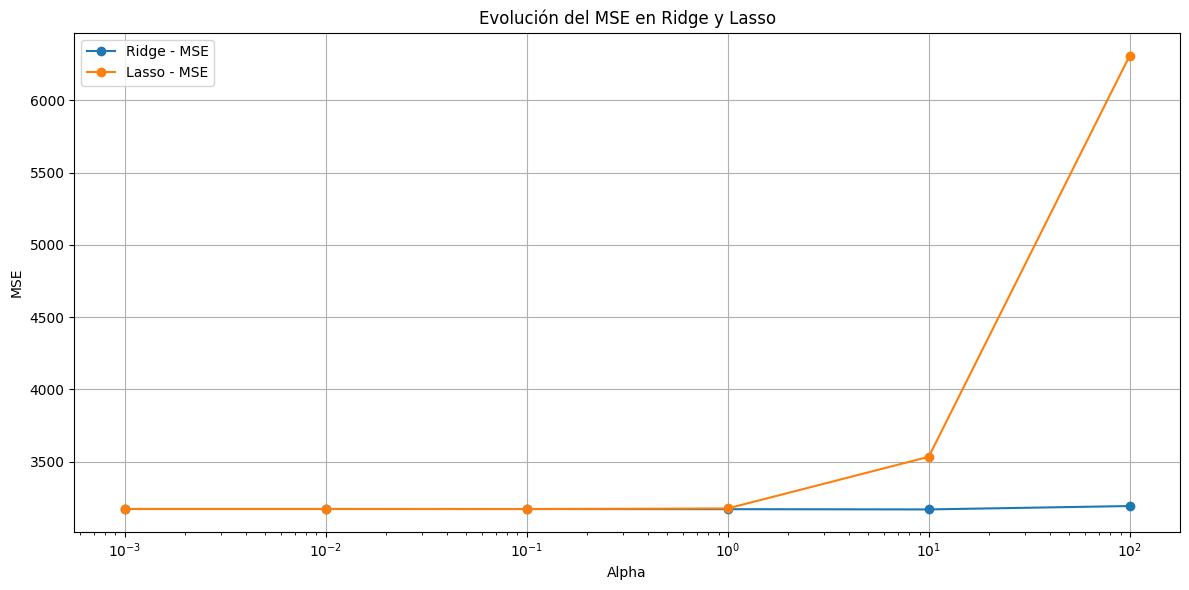

In [13]:

# Visualización de comparación
plt.figure(figsize=(12, 6))
for modelo in ['Ridge', 'Lasso']:
    subset = df_resultados[df_resultados['Modelo'] == modelo]
    plt.plot(subset['Alpha'], subset['MSE'], marker='o', label=f"{modelo} - MSE")

plt.title("Evolución del MSE en Ridge y Lasso")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Comentarios:
# Ridge penaliza los coeficientes al cuadrado (L2), útil para evitar sobreajuste
# Lasso penaliza con valor absoluto (L1), además puede eliminar variables (coeficientes = 0)
# El parámetro alpha controla la fuerza de la regularización


## Gradient Boosting Regressor (GBR)

In [18]:
# Modelo de regresión más potente que pueda capturar relaciones no lineales y manejar interacciones entre variables automáticamente.

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar y escalar datos
data = load_diabetes()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2025)

# Modelo básico sin ajuste de hiperparámetros
gb_basic = GradientBoostingRegressor(random_state=2025)
gb_basic.fit(X_train, y_train)
y_pred_basic = gb_basic.predict(X_test)

mse = mean_squared_error(y_test, y_pred_basic)
mae = mean_absolute_error(y_test, y_pred_basic)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_basic)

print("\nEvaluación del modelo básico (GradientBoostingRegressor):")
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))





Evaluación del modelo básico (GradientBoostingRegressor):
MSE: 3749.15
MAE: 50.29
RMSE: 61.23
R2: 0.4018


In [19]:
# Optimización con GridSearchCV

param_grid = {
    'n_estimators': [100, 200],           # Número de árboles
    'learning_rate': [0.05, 0.1, 0.2],    # Cuánto contribuye cada árbol
    'max_depth': [3, 5, 7],               # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],      # Muestras mínimas para dividir
    'min_samples_leaf': [1, 2, 4]         # Muestras mínimas por hoja
}

gb_model = GradientBoostingRegressor(random_state=2025)
grid_search = GridSearchCV(estimator=gb_model,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=2,
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train, y_train)

# Evaluación del mejor modelo
y_pred_opt = grid_search.best_estimator_.predict(X_test)
mse_opt = mean_squared_error(y_test, y_pred_opt)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mse_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print("\nEvaluación del mejor modelo (GradientBoostingRegressor optimizado):")
print("Mejores hiperparámetros:", grid_search.best_params_)
print("MSE:", round(mse_opt, 2))
print("MAE:", round(mae_opt, 2))
print("RMSE:", round(rmse_opt, 2))
print("R2:", round(r2_opt, 4))

# Este modelo explica aproximadamente el 42% de la varianza y tiene un error más bajo que su versión básica.


Fitting 2 folds for each of 162 candidates, totalling 324 fits

Evaluación del mejor modelo (GradientBoostingRegressor optimizado):
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
MSE: 3531.03
MAE: 49.62
RMSE: 59.42
R2: 0.4366


## HistGradientBoostingRegressor

In [16]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor

# Usamos los mismos datos escalados que antes

# Modelo básico de HistGradientBoosting (más rápido y eficiente en grandes volúmenes)
hgb_model = HistGradientBoostingRegressor(random_state=2025)
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_hgb)
mae = mean_absolute_error(y_test, y_pred_hgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_hgb)

print("\nEvaluación del modelo básico (HistGradientBoostingRegressor):")
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

# Comentarios:
# Este modelo usa histogramas para acelerar el entrenamiento.
# Es una alternativa moderna y más eficiente al GradientBoosting clásico.
# Puede manejar valores faltantes directamente (no aplicable aquí).
# Se recomienda como base sólida para tareas de regresión estructurada.

# Diferencias con GradientBoostingRegressor:
# Usa histogramas en lugar de árboles tradicionales: esto reduce tiempo y memoria.
# Soporta valores faltantes de forma nativa, sin necesidad de imputarlos.
# Entrena más rápido y escala mejor en conjuntos de datos grandes.
# Requiere habilitar el módulo experimental en versiones anteriores de scikit-learn.
# Recomendado cuando se quiere eficiencia sin sacrificar precisión.

# Resultados:
# Es más rápido y eficiente, pero su precisión fue inferior en este caso concreto.



Evaluación del modelo básico (HistGradientBoostingRegressor):
MSE: 4053.95
MAE: 52.82
RMSE: 63.67
R2: 0.3531


/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [17]:
# Una última mejora:
# Optimización de hiperparámetros con GridSearchCV
# ================================
# Podemos mejorar el modelo ajustando:
# - learning_rate: cuánto aprende cada árbol
# - max_iter: número de árboles (como n_estimators)
# - max_depth: qué tan profundo puede ser cada árbol
# - min_samples_leaf: mínimo de muestras por hoja (más alto = más regularización)
# - l2_regularization: penalización para evitar sobreajuste
# - max_bins: discretización de las variables (más bins = más precisión, pero más coste)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [20, 30, 50],
    'l2_regularization': [0.0, 1.0, 5.0],
    'max_bins': [255, 128]
}

hgb = HistGradientBoostingRegressor(random_state=2025)

grid_search_hgb = GridSearchCV(
    estimator=hgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_search_hgb.fit(X_train, y_train)

# Evaluación final con el mejor modelo
best_hgb = grid_search_hgb.best_estimator_
y_pred_best_hgb = best_hgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_best_hgb)
mae = mean_absolute_error(y_test, y_pred_best_hgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best_hgb)

print("Evaluación del mejor HistGradientBoostingRegressor:")
print("Mejores hiperparámetros:", grid_search_hgb.best_params_)
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))
hgb_model = HistGradientBoostingRegressor(random_state=2025)
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_hgb)
mae = mean_absolute_error(y_test, y_pred_hgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_hgb)

print("\nEvaluación del modelo básico (HistGradientBoostingRegressor):")
print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

# Comparación entre HistGradientBoosting básico y optimizado

# Modelo básico:
# - MSE: 4053.95
# - MAE: 52.82
# - RMSE: 63.67
# - R2: 0.3531
# Modelo rápido, pero con errores más altos y menor capacidad explicativa.

# Modelo optimizado (GridSearchCV):
# - Mejores hiperparámetros: {'l2_regularization': 5.0, 'learning_rate': 0.05,
#                              'max_bins': 128, 'max_depth': None,
#                              'max_iter': 100, 'min_samples_leaf': 50}
# - MSE: 3595.33
# - MAE: 49.33
# - RMSE: 59.96
# - R2: 0.4263
# El modelo comete menos errores, es más robusto y generaliza mejor.

# Conclusión:
# - La búsqueda de hiperparámetros ha sido efectiva.
# - Las técnicas de regularización aplicadas (como l2 y min_samples_leaf) han reducido el sobreajuste.
# - Este sería el modelo para usar.

Fitting 10 folds for each of 486 candidates, totalling 4860 fits
Evaluación del mejor HistGradientBoostingRegressor:
Mejores hiperparámetros: {'l2_regularization': 5.0, 'learning_rate': 0.05, 'max_bins': 128, 'max_depth': None, 'max_iter': 100, 'min_samples_leaf': 50}
MSE: 3595.33
MAE: 49.33
RMSE: 59.96
R2: 0.4263

Evaluación del modelo básico (HistGradientBoostingRegressor):
MSE: 4053.95
MAE: 52.82
RMSE: 63.67
R2: 0.3531
